In [1]:
REPO_URL = "https://github.com/vuhoangviet0808/llm-uav-.git"  # <-- edit this
REPO_DIR = REPO_URL.rstrip('/').split('/')[-1].replace('.git', '')

import os
if not os.path.isdir(REPO_DIR):
    !git clone $REPO_URL
%cd $REPO_DIR

Cloning into 'llm-uav-'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 39 (delta 10), reused 35 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 28.94 KiB | 4.82 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/kaggle/working/llm-uav-


In [2]:
!nvidia-smi

Sun Aug 16 15:17:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.5 MB/s eta 0:00:0000:0100:01


In [4]:
from huggingface_hub import login
login()

In [5]:
!python -m src.data_gen --config configs/default.yaml

[train] wrote 3000 examples to data/train.jsonl (avg optimal path length = 7.3)
[val] wrote 200 examples to data/val.jsonl (avg optimal path length = 7.2)
[test] wrote 200 examples to data/test.jsonl (avg optimal path length = 7.0)


In [6]:
!python -m src.evaluate --config configs/default.yaml \
    --report_path outputs/eval_report_base.json --limit 50

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
config.json: 100%|█████████████████████████████| 660/660 [00:00<00:00, 2.23MB/s]
tokenizer_config.json: 7.30kB [00:00, 11.3MB/s]
vocab.json: 2.78MB [00:00, 96.0MB/s]
merges.txt: 1.67MB [00:00, 107MB/s]
tokenizer.json: 7.03MB [00:00, 137MB/s]
model.safetensors: 100%|████████████████████| 3.09G/3.09G [00:14<00:00, 220MB/s]
Loading weights: 100%|█| 338/338 [00:00<00:00, 1396.36it/s, Materializing param=
evaluating: 100%|█████| 50/50 [28:40<00:00, 34.41s/ex, invalid=31, success=0/50]
{
  "n_examples": 50,
  "success_rate": 0.0,
  "invalid_move_rate": 0.62,
  "unparseable_rate": 0.0,
  "avg_length_ratio_on_success": null
}
Full report written to outputs/eval_report_base.json


In [7]:
!python -m src.train --config configs/default.yaml

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading base model 'Qwen/Qwen2.5-1.5B-Instruct' ...
Loading weights: 100%|█| 338/338 [00:00<00:00, 1537.41it/s, Materializing param=
trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815
{'loss': '1.421', 'grad_norm': '0.9074', 'learning_rate': '0.0001865', 'epoch': '0.2133'}
{'loss': '0.7682', 'grad_norm': '0.9657', 'learning_rate': '0.0001723', 'epoch': '0.4267'}
{'loss': '0.729', 'grad_norm': '1.005', 'learning_rate': '0.0001582', 'epoch': '0.64'}
{'loss': '0.7053', 'grad_norm': '0.8121', 'learning_rate': '0.000144', 'epoch': '0.8533'}
{'loss': '0.6402', 'grad_norm': '1.014', 'learning_rate': '0.0001298', 'epoch': '1.064'}
{'loss': '0.5706', 'grad_norm': '1.879', 'learning_rate': '0.0001156', 'epoch': '1.277'}
{'loss': '0.5514', 'grad_norm': '1.769', 'learning_rate': '0.0001014', 'epoch': '1.491'}
{'loss': '0.539', 'grad_norm': '1.762'

In [8]:
!python -m src.evaluate --config configs/default.yaml \
    --adapter_dir outputs/lora-pathfinding \
    --report_path outputs/eval_report_finetuned.json

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100%|█| 338/338 [00:00<00:00, 1619.10it/s, Materializing param=
evaluating:   0%|                                       | 0/200 [00:00<?, ?ex/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
evaluating: 100%|█| 200/200 [50:02<00:00, 15.01s/ex, invalid=114, success=70/200
{
  "n_examples": 200,
  "success_rate": 0.35,
  "invalid_move_rate": 0.57,
  "unparseable_rate": 0.0,
  "avg_length_ratio_on_success": 1.0
}
Full report written to outputs/eval_report_finetuned.json


In [9]:
import json
base = json.load(open("outputs/eval_report_base.json"))["summary"]
ft = json.load(open("outputs/eval_report_finetuned.json"))["summary"]
print("BASE      :", base)
print("FINE-TUNED:", ft)

BASE      : {'n_examples': 50, 'success_rate': 0.0, 'invalid_move_rate': 0.62, 'unparseable_rate': 0.0, 'avg_length_ratio_on_success': None}
FINE-TUNED: {'n_examples': 200, 'success_rate': 0.35, 'invalid_move_rate': 0.57, 'unparseable_rate': 0.0, 'avg_length_ratio_on_success': 1.0}


Saved outputs/example.png


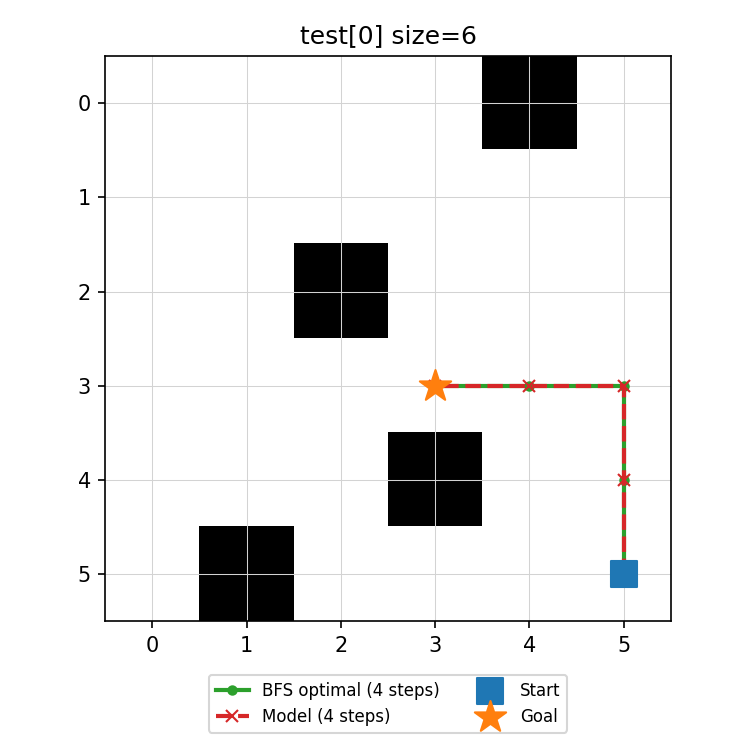

In [10]:
!python -m src.visualize --config configs/default.yaml --split test --index 0 \
    --eval_report outputs/eval_report_finetuned.json --out outputs/example.png

from IPython.display import Image
Image("outputs/example.png")